# Book recommender data preprocessing

This notebook prepares the raw Book-Crossing datasets for recommender models.

The workflow has four parts:

1. Load the raw books, users, and ratings tables.
2. Clean the books table and construct a stable `book_id` that groups different ISBN editions of the same title and author.
3. Clean the users and ratings tables so they can be joined reliably.
4. Export cleaned datasets that are convenient for recommendation experiments.

The outputs created at the end are:

- `cleaned_books.csv`: cleaned book metadata at the ISBN level, enriched with rating statistics
- `cleaned_users.csv`: cleaned user metadata
- `cleaned_ratings.csv`: ratings matched to `book_id`

## Imports and display settings

The notebook uses pandas for data and matplotlib for visual inspection.
A small plotting setup is added to keep the charts visually consistent across sections.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import unicodedata

plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10


def print_section_summary(name: str, df: pd.DataFrame) -> None:
    """Print a compact overview of a dataframe."""
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} columns")
    display(df.head(3))

## Load the raw data

The raw files are read from the local `../data/raw` directory.

In [2]:

data_path = "../data/raw"
books_path = os.path.join(data_path, "Books.csv")
users_path = os.path.join(data_path, "Users.csv")
ratings_path = os.path.join(data_path, "Ratings.csv")

books_df = pd.read_csv(books_path, encoding="utf-8", low_memory=False)
users_df = pd.read_csv(users_path, encoding="utf-8")
ratings_df = pd.read_csv(ratings_path)

print_section_summary("Raw books", books_df)
print_section_summary("Raw users", users_df)
print_section_summary("Raw ratings", ratings_df)


Raw books: 271,360 rows × 8 columns


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...


Raw users: 278,858 rows × 3 columns


,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN


Raw ratings: 1,149,780 rows × 3 columns


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0


## Books: standardize columns and build a grouped book identifier

The raw books table stores books at the ISBN level, which means the same title can appear multiple times across editions.
For recommendation experiments it is useful to create a stable `book_id` that groups rows sharing the same normalized title and author.

This section:

- standardizes column names
- keeps only the large cover image URL
- removes duplicate ISBN rows
- creates a normalized `(title, author)` key
- assigns a deterministic integer `book_id`

In [3]:
books = books_df.copy()

books = books.drop(columns=["Image-URL-S", "Image-URL-M"]).rename(
    columns={
        "ISBN": "isbn",
        "Book-Title": "title",
        "Book-Author": "author",
        "Year-Of-Publication": "year",
        "Publisher": "publisher",
        "Image-URL-L": "image_url",
    }
)

print(f"Books before ISBN deduplication: {len(books):,}")
books = books.drop_duplicates(subset=["isbn"], keep="first").reset_index(drop=True)
print(f"Books after ISBN deduplication:  {len(books):,}")


def normalize_text(value: object) -> str:
    """Normalize free text for deterministic matching."""
    if pd.isna(value):
        return ""
    value = str(value)
    value = unicodedata.normalize("NFKC", value)
    value = value.strip().lower()
    value = " ".join(value.split())
    return value


books["title_norm"] = books["title"].map(normalize_text)
books["author_norm"] = books["author"].map(normalize_text)
books["title_author_key"] = books["title_norm"] + " || " + books["author_norm"]

books = books.sort_values(["title_author_key", "isbn"], kind="mergesort").reset_index(drop=True)
books["book_id"] = pd.factorize(books["title_author_key"])[0] + 1

books = books.drop(columns=["title_norm", "author_norm", "title_author_key"])

print_section_summary("Books after column cleanup", books)
print(f"Unique grouped books (book_id): {books['book_id'].nunique():,}")

Books before ISBN deduplication: 271,360
Books after ISBN deduplication:  271,360
Books after column cleanup: 271,360 rows × 7 columns


,isbn,title,author,year,publisher,image_url,book_id
0,1565920317,!%@ (A Nutshell handbook),Donnalyn Frey,1993,O'Reilly,http://images.amazon.com/images/P/1565920317.0...,1
1,1565920465,!%@ (A Nutshell handbook),Donnalyn Frey,1994,O'Reilly,http://images.amazon.com/images/P/1565920465.0...,1
2,0133989429,!Arriba! Comunicacion y cultura,Eduardo Zayas-Bazan,1996,Prentice Hall,http://images.amazon.com/images/P/0133989429.0...,2


Unique grouped books (book_id): 248,154


## Books: inspect missing values and publication year

The publication year field needs extra care because the raw dataset contains:

- text values in the year column
- shifted rows where year and publisher were displaced
- implausible years such as `0` or years after the dataset snapshot

The next cells repair the known shifted rows, convert the column to numeric, visualize the distribution, and mark implausible values as missing.

In [4]:
print("Missing values in the books table:")
display(books.isna().sum().to_frame("missing_values"))

Missing values in the books table:


,missing_values
isbn,0
title,0
author,2
year,0
publisher,2
image_url,3
book_id,0


In [5]:
print(sorted(books["year"].unique()))

['0', '1376', '1378', '1806', '1897', '1900', '1901', '1902', '1904', '1906', '1908', '1909', '1910', '1911', '1914', '1917', '1919', '1920', '1921', '1922', '1923', '1924', '1925', '1926', '1927', '1928', '1929', '1930', '1931', '1932', '1933', '1934', '1935', '1936', '1937', '1938', '1939', '1940', '1941', '1942', '1943', '1944', '1945', '1946', '1947', '1948', '1949', '1950', '1951', '1952', '1953', '1954', '1955', '1956', '1957', '1958', '1959', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2008', '2010', '2011', '2012', '2020', '2021', '2024', '2026', '2030', '2037', '2038', '2050', 'DK Publishing Inc', 'Gallimard']


In [6]:
isbns_to_repair = books.loc[books["year"] == "DK Publishing Inc", "isbn"].tolist()
isbns_to_repair += books.loc[books["year"] == "Gallimard", "isbn"].tolist()

books.loc[books["isbn"].isin(isbns_to_repair), :]

,isbn,title,author,year,publisher,image_url,book_id
59498,0789466953,"DK Readers: Creating the X-Men, How Comic Book...",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.0...,NaN,54645
59499,078946697X,"DK Readers: Creating the X-Men, How It All Beg...",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.0...,NaN,54646
156739,2070426769,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-M...",2003,Gallimard,http://images.amazon.com/images/P/2070426769.0...,NaN,143854


In [7]:
# name of author in book title column: Title\";Author_name"
cols = books.columns.to_list()
mask = books["isbn"].isin(isbns_to_repair)

title_author = books.loc[mask, "title"].astype(str).str.split(r'\\\";|\";|";', n=1, expand=True)
true_title = title_author[0].astype("string").str.replace(r'\\\"$', '', regex=True).str.strip()
true_author_from_title = title_author[1].astype("string").str.strip()

for i in range(len(cols)-2, 2, -1):
    books.loc[mask, cols[i]] = books.loc[mask, cols[i-1]]

books.loc[mask, "title"] = true_title
books.loc[mask, "author"] = true_author_from_title

books.loc[mask, cols]

,isbn,title,author,year,publisher,image_url,book_id
59498,0789466953,"DK Readers: Creating the X-Men, How Comic Book...","James Buckley""",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.0...,54645
59499,078946697X,"DK Readers: Creating the X-Men, How It All Beg...","Michael Teitelbaum""",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.0...,54646
156739,2070426769,"Peuple du ciel, suivi de 'Les Bergers","Jean-Marie Gustave Le ClÃ?Â©zio""",2003,Gallimard,http://images.amazon.com/images/P/2070426769.0...,143854


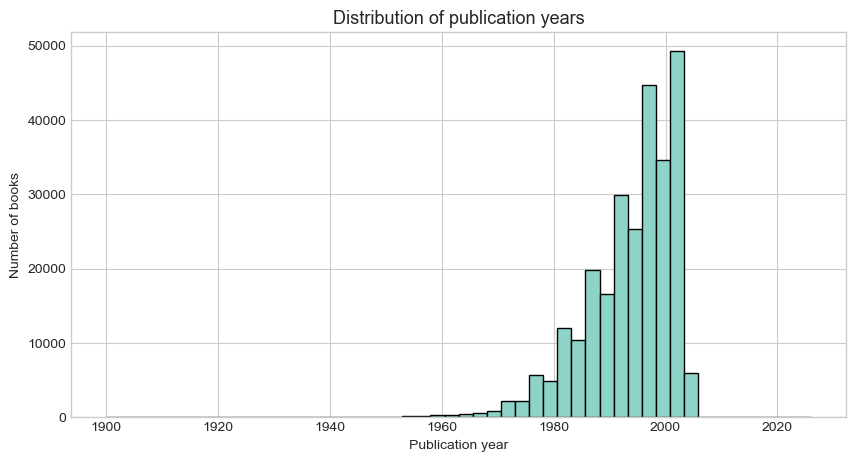

Records with year == 0: 4,618
Records with year > 2005: 26


In [8]:
books["year"] = pd.to_numeric(books["year"], errors="coerce").astype("Int32")

years_for_plot = books["year"].dropna()
years_for_plot = years_for_plot[(years_for_plot >= 1900) & (years_for_plot <= 2026)]

# fig, ax = plt.subplots()
fig, ax = plt.subplots(facecolor="white")
ax.set_facecolor("white")

ax.hist(years_for_plot, bins=50, edgecolor="black")
ax.set_title("Distribution of publication years")
ax.set_xlabel("Publication year")
ax.set_ylabel("Number of books")
plt.show()

invalid_zero = (books["year"] == 0).sum()
invalid_future = (books["year"] > 2005).sum()
print(f"Records with year == 0: {invalid_zero:,}")
print(f"Records with year > 2005: {invalid_future:,}")

## Books: filter the year range used in the cleaned catalog

Years equal to `0` and years after 2005 are treated as unreliable in this dataset and replaced with missing values.
Older books are retained only if they fall above the chosen lower bound.

The resulting `filtered_books` table is the main book catalog used in the remainder of the notebook.

In [9]:
books.loc[books["year"] == 0, "year"] = pd.NA
books.loc[books["year"] > 2005, "year"] = pd.NA

current_year = 2005
lower_bound = 1900

filtered_books = books[
    (((books["year"] < current_year) & (books["year"] > lower_bound)) | books["year"].isna())
].copy()

print(f"Books after year filtering: {len(filtered_books):,}")
print(f"Unique grouped books after year filtering: {filtered_books['book_id'].nunique():,}")

display(
    filtered_books[["book_id", "isbn", "title", "author", "year", "publisher"]].head(10)
)

Books after year filtering: 271,307
Unique grouped books after year filtering: 248,108


,book_id,isbn,title,author,year,publisher
0,1,1565920317,!%@ (A Nutshell handbook),Donnalyn Frey,1993,O'Reilly
1,1,1565920465,!%@ (A Nutshell handbook),Donnalyn Frey,1994,O'Reilly
2,2,0133989429,!Arriba! Comunicacion y cultura,Eduardo Zayas-Bazan,1996,Prentice Hall
3,3,013327974X,"!Trato hecho!: Spanish for Real Life, Combined...",John T. McMinn,1995,Prentice Hall
4,4,0452279186,!Yo!,Julia Alvarez,1997,Plume Books
5,5,0836218205,$14 In The Bank (Cathy Collection),Cathy Guisewite,1990,Andrews McMeel Publishing
6,6,1592000673,$30 Film School,Michael W. Dean,2003,Muska &amp; Lipman Publishing
7,7,1588204030,$oft Money: The True Power in Our Nation's Cap...,E. L. Burton,2000,1stBooks Library
8,8,0812506448,$Weet Deal$,Brian Lysaght,1986,Tor Books
9,9,0563208422,' Allo 'Allo: the War Diaries of Rene Artois,John Haselden,1989,BBC Consumer Publishing


## Users: clean metadata and normalize age

The user table is much smaller than the booka table, but it still contains noisy age values and a text location field.
This section standardizes the columns, marks implausible ages as missing, and later extracts a cleaner country field.

In [10]:
users = users_df.copy().rename(
    columns={
        "User-ID": "user_id",
        "Location": "location",
        "Age": "age",
    }
)

print(f"Users before deduplication: {len(users):,}")
users = users.drop_duplicates(subset=["user_id"], keep="first").reset_index(drop=True)
print(f"Users after deduplication:  {len(users):,}")

users["age"] = pd.to_numeric(users["age"], errors="coerce").astype("Int64")

higher_age_bound = 100
lower_age_bound = 5
users.loc[(users["age"] < lower_age_bound) | (users["age"] > higher_age_bound), "age"] = pd.NA

print(f"Missing ages after cleanup: {users['age'].isna().sum():,} "
      f"({users['age'].isna().mean() * 100:.2f}%)")

Users before deduplication: 278,858
Users after deduplication:  278,858
Missing ages after cleanup: 112,010 (40.17%)


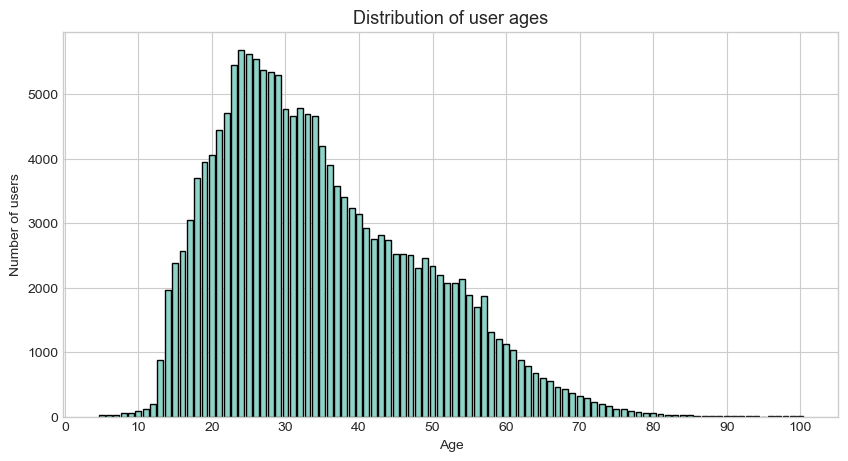

In [11]:
age_counts = users["age"].dropna().value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(age_counts.index, age_counts.values, edgecolor="black")
ax.set_title("Distribution of user ages")
ax.set_xlabel("Age")
ax.set_ylabel("Number of users")
ax.set_xticks(range(0, 101, 10))
plt.show()

## Users: split location and clean country labels

The raw location field contains comma-separated fragments such as city, state, and country.
We split the string into separate parts, normalize country names, and collapse rare country labels into missing values to reduce noise.

In [12]:

location_split = users["location"].str.split(",", n=2, expand=True)
users["city"] = location_split[0].str.strip().astype("string")
users["state"] = location_split[1].str.strip().astype("string")
users["country"] = location_split[2].str.strip().astype("string")

country = (
    users["country"]
    .str.strip()
    .str.replace(r'^[\'"]+|[\'"]+$', "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
)

country_lower = country.str.lower()
missing_like = {"", '""', "n/a", "na", "none", "null", "nan", "unknown", ",", '"', "the", "c", "<NA>"}
country_lower = country_lower.mask(country_lower.isin(missing_like), pd.NA)

normalize_country = {
    "us": "usa",
    "u.s.": "usa",
    "u.s.a.": "usa",
    "united states": "usa",
    "united states of america": "usa",
    "uk": "united kingdom",
    "u.k.": "united kingdom",
    "u.k": "united kingdom",
    "england": "united kingdom",
    "l`italia": "italy",
    "italia": "italy",
    "deutschland": "germany",
    "españa": "spain",
    "espaã±a": "spain",
    "espaã?â±a": "spain",
    "u.a.e.": "united arab emirates",
    "u.a.e": "united arab emirates",
    "la france": "france",
    "la argentina": "argentina",
    "dominica": "dominican republic",
}

users["country"] = country_lower.replace(normalize_country).astype("string")

country_counts = users["country"].value_counts(dropna=False)
countries_to_nan = country_counts[country_counts < 5].index.tolist()
users.loc[users["country"].isin(countries_to_nan), "country"] = pd.NA

users = users.drop(columns=["location", "city", "state"])

display(users.head())
print(f"Unique non-missing countries after cleanup: {users['country'].dropna().nunique():,}")

,user_id,age,country
0,1,<NA>,usa
1,2,18,usa
2,3,<NA>,russia
3,4,17,portugal
4,5,<NA>,united kingdom


Unique non-missing countries after cleanup: 218


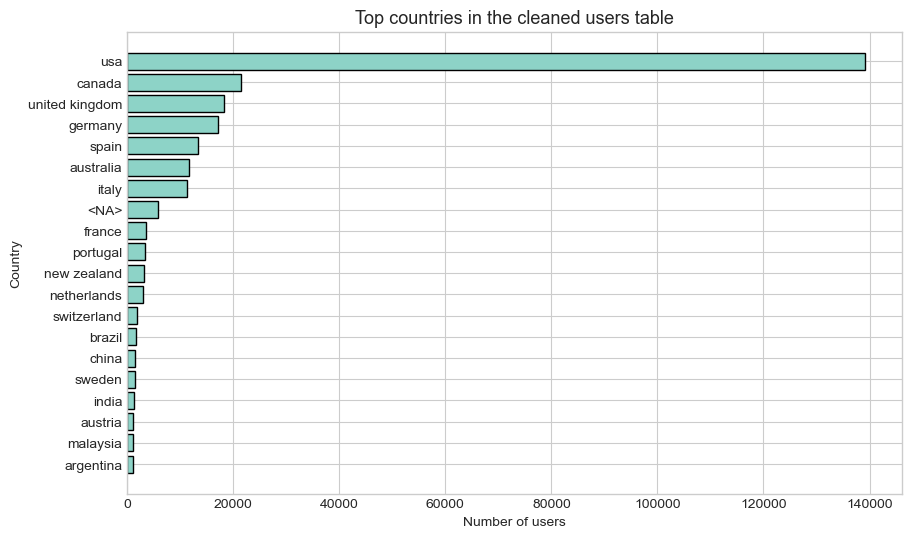

In [13]:
country_counts = users["country"].value_counts(dropna=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(country_counts.index.astype(str)[::-1], country_counts.values[::-1], edgecolor="black")
ax.set_title("Top countries in the cleaned users table")
ax.set_xlabel("Number of users")
ax.set_ylabel("Country")
plt.show()

## Ratings: standardize columns and attach `book_id`

The raw ratings table is linked to books by ISBN.
After the books table has been cleaned, each rating can be mapped to the grouped `book_id`, which allows the recommender to aggregate across different editions of the same book.

In [14]:
ratings = ratings_df.copy().rename(
    columns={
        "User-ID": "user_id",
        "ISBN": "isbn",
        "Book-Rating": "book_rating",
    }
)

ratings = ratings[ratings["isbn"].isin(filtered_books["isbn"])].copy()

isbn_book_id = filtered_books[["isbn", "book_id"]].drop_duplicates()
ratings = ratings.merge(isbn_book_id, on="isbn", how="left")

print(f"Ratings before deduplication: {len(ratings):,}")
ratings = ratings.drop_duplicates(subset=["user_id", "isbn"], keep="first").reset_index(drop=True)
print(f"Ratings after deduplication:  {len(ratings):,}")

display(ratings.head())

Ratings before deduplication: 1,031,006
Ratings after deduplication:  1,031,006


,user_id,isbn,book_rating,book_id
0,276725,034545104X,0,69935
1,276726,0155061224,5,155136
2,276727,0446520802,0,207251
3,276729,052165615X,3,84713
4,276729,0521795028,6,180716


## Ratings: inspect implicit and explicit feedback

In this dataset, a rating of `0` means implicit feedback, while values from `1` to `10` are explicit ratings.
Both views are useful:

- the implicit/explicit split shows how much direct preference information is available
- the explicit distribution shows which rating values are most common

Implicit ratings: 647,220 (62.78%)
Explicit ratings: 383,786 (37.22%)


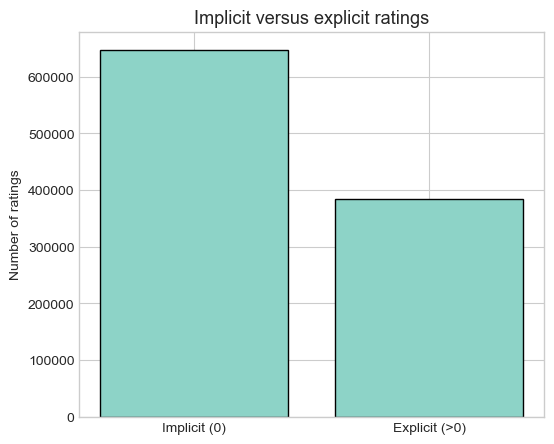

In [15]:
implicit_ratings = ratings[ratings["book_rating"] == 0].copy()
explicit_ratings = ratings[ratings["book_rating"] > 0].copy()

num_implicit = len(implicit_ratings)
num_explicit = len(explicit_ratings)

print(f"Implicit ratings: {num_implicit:,} ({num_implicit / len(ratings) * 100:.2f}%)")
print(f"Explicit ratings: {num_explicit:,} ({num_explicit / len(ratings) * 100:.2f}%)")

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(["Implicit (0)", "Explicit (>0)"], [num_implicit, num_explicit], edgecolor="black")
ax.set_title("Implicit versus explicit ratings")
ax.set_ylabel("Number of ratings")
plt.show()

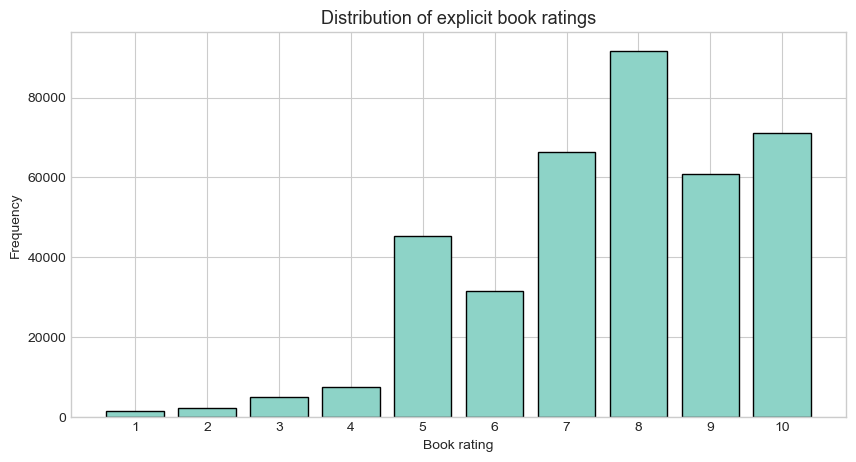

In [16]:
explicit_counts = explicit_ratings["book_rating"].value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(explicit_counts.index.astype(str), explicit_counts.values, edgecolor="black")
ax.set_title("Distribution of explicit book ratings")
ax.set_xlabel("Book rating")
ax.set_ylabel("Frequency")
plt.show()

## Ratings: user and book activity

The next cells summarize how many interactions each user and each book receives.
These distributions are important because recommender quality depends strongly on how sparse the data is.

In [17]:
n_unique_users = ratings["user_id"].nunique()
n_unique_books = ratings["book_id"].nunique()

print(f"Unique users in ratings: {n_unique_users:,}")
print(f"Unique books in ratings: {n_unique_books:,}")

ratings_per_user = ratings.groupby("user_id").size()
ratings_per_book = ratings.groupby("book_id").size()

display(ratings_per_user.describe().to_frame("ratings_per_user"))
display(ratings_per_book.describe().to_frame("ratings_per_book"))

Unique users in ratings: 92,099
Unique books in ratings: 247,017


,ratings_per_user
count,92099.000000
mean,11.194541
std,88.679800
min,1.000000
25%,1.000000
50%,1.000000
75%,4.000000
max,11143.000000


,ratings_per_book
count,247017.000000
mean,4.173826
std,16.436763
min,1.000000
25%,1.000000
50%,1.000000
75%,3.000000
max,2502.000000


In [18]:
top_users = ratings.groupby("user_id")["book_id"].count().sort_values(ascending=False)
print("Top 20 users by number of ratings:")
display(top_users.head(20).to_frame("n_ratings"))

Top 20 users by number of ratings:


,n_ratings
user_id,
11676,11143
198711,6456
153662,5813
98391,5778
35859,5646
212898,4289
278418,3996
76352,3329
110973,2971


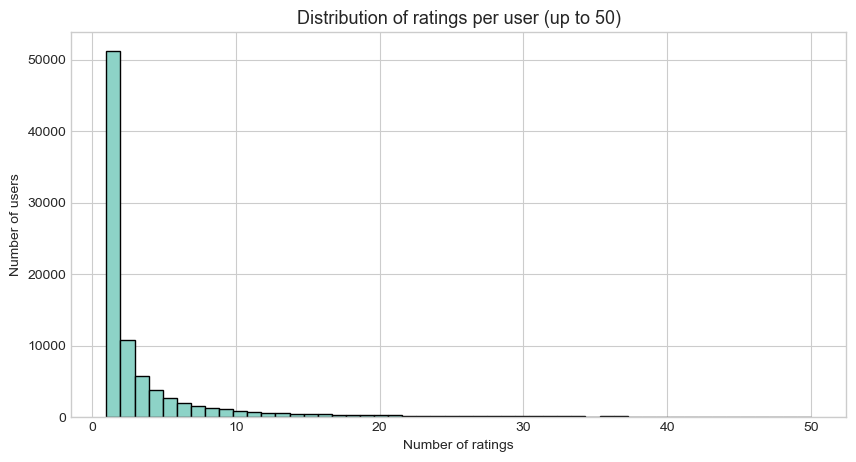

In [19]:
user_hist = top_users[top_users <= 50]

fig, ax = plt.subplots()
ax.hist(user_hist, bins=50, edgecolor="black")
ax.set_title("Distribution of ratings per user (up to 50)")
ax.set_xlabel("Number of ratings")
ax.set_ylabel("Number of users")
plt.show()

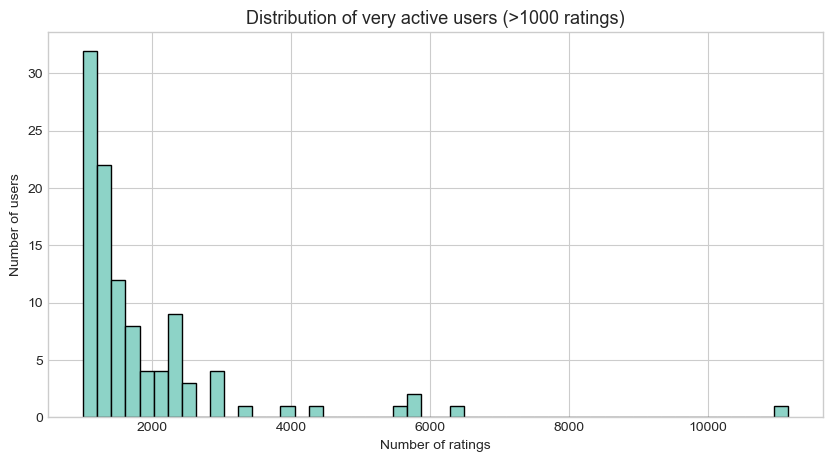

In [20]:
very_active_users = top_users[top_users > 1000]

if not very_active_users.empty:
    fig, ax = plt.subplots()
    ax.hist(very_active_users, bins=50, edgecolor="black")
    ax.set_title("Distribution of very active users (>1000 ratings)")
    ax.set_xlabel("Number of ratings")
    ax.set_ylabel("Number of users")
    plt.show()
else:
    print("No users with more than 1000 ratings were found.")

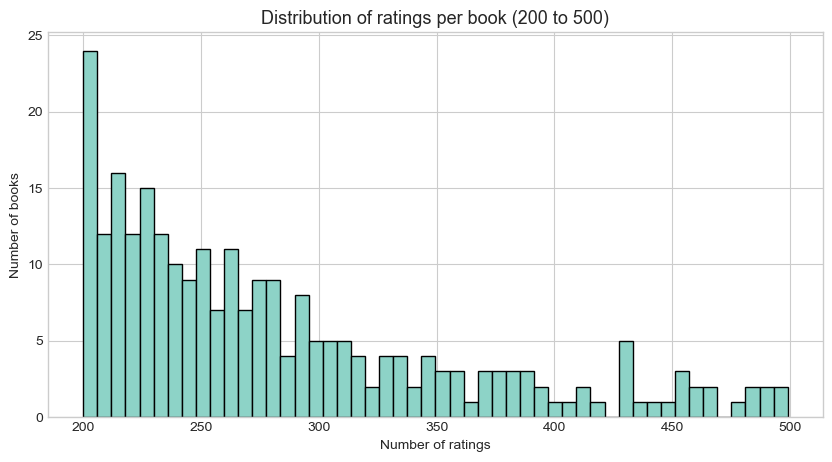

In [21]:
book_hist = ratings_per_book[(ratings_per_book >= 200) & (ratings_per_book <= 500)]


fig, ax = plt.subplots()
ax.hist(book_hist, bins=50, edgecolor="black")
ax.set_title("Distribution of ratings per book (200 to 500)")
ax.set_xlabel("Number of ratings")
ax.set_ylabel("Number of books")
plt.show()

In [22]:
books_with_counts = filtered_books.merge(
    ratings_per_book.rename("num_ratings"),
    on="book_id",
    how="left",
)

display(
    books_with_counts.sort_values("num_ratings", ascending=False)[
        ["book_id", "title", "author", "num_ratings"]
    ].head(20)
)

average_rating_per_book = explicit_ratings.groupby("book_id")["book_rating"].mean()
display(average_rating_per_book.describe().to_frame("explicit_mean_rating"))

,book_id,title,author,num_ratings
264681,242026,Wild Animus,Rich Shapero,2502.0
221899,203104,The Lovely Bones: A Novel,Alice Sebold,1295.0
206634,189376,The Da Vinci Code,Dan Brown,898.0
206633,189376,The Da Vinci Code,DAN BROWN,898.0
206629,189376,The Da Vinci Code,Dan Brown,898.0
206632,189376,The Da Vinci Code,DAN BROWN,898.0
206630,189376,The Da Vinci Code,Dan Brown,898.0
206631,189376,The Da Vinci Code,DAN BROWN,898.0
6159,5716,A Painted House,JOHN GRISHAM,838.0
6158,5716,A Painted House,JOHN GRISHAM,838.0


,explicit_mean_rating
count,138019.000000
mean,7.520665
std,1.710761
min,1.000000
25%,6.500000
50%,8.000000
75%,9.000000
max,10.000000


## Create rating statistics at the ISBN level

To enrich the cleaned books table, we aggregate rating statistics for each ISBN:

- number of implicit ratings
- number of explicit ratings
- total number of ratings
- mean explicit rating

These features can later be used for filtering, ranking, or dataset inspection.

In [23]:
isbn_stats = (
    ratings.groupby("isbn", dropna=False)
    .agg(
        implicit_ratings=("book_rating", lambda s: (s == 0).sum()),
        explicit_ratings=("book_rating", lambda s: (s > 0).sum()),
        avg_explicit_rating=("book_rating", lambda s: s[s > 0].mean()),
        total_ratings=("book_rating", "size"),
    )
    .reset_index()
)

books_filtered = filtered_books.merge(isbn_stats, on="isbn", how="left")

books_filtered["implicit_ratings"] = books_filtered["implicit_ratings"].fillna(0).astype(int)
books_filtered["explicit_ratings"] = books_filtered["explicit_ratings"].fillna(0).astype(int)
books_filtered["total_ratings"] = books_filtered["total_ratings"].fillna(0).astype(int)

display(
    books_filtered.sort_values("explicit_ratings", ascending=False)[
        ["book_id", "title", "author", "isbn", "implicit_ratings", "explicit_ratings", "avg_explicit_rating"]
    ].head(20)
)

,book_id,title,author,isbn,implicit_ratings,explicit_ratings,avg_explicit_rating
221899,203104,The Lovely Bones: A Novel,Alice Sebold,0316666343,588,707,8.185290
264681,242026,Wild Animus,Rich Shapero,0971880107,1921,581,4.390706
206629,189376,The Da Vinci Code,Dan Brown,0385504209,396,487,8.435318
231401,211699,The Red Tent (Bestselling Backlist),Anita Diamant,0312195516,340,383,8.182768
59354,54522,Divine Secrets of the Ya-Ya Sisterhood: A Novel,Rebecca Wells,0060928336,412,320,7.887500
90225,82717,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling,059035342X,258,313,8.939297
233890,213912,The Secret Life of Bees,Sue Monk Kidd,0142001740,308,307,8.452769
262801,240288,Where the Heart Is (Oprah's Book Club (Paperba...,Billie Letts,0446672211,290,295,8.142373
6160,5716,A Painted House,John Grisham,044023722X,366,281,7.338078
83979,77024,Girl with a Pearl Earring,Tracy Chevalier,0452282152,248,278,7.982014


## Aggregate books across editions into `books_by_bookid`

The ISBN-level table is still edition-specific.
For recommendation methods that operate on grouped books, we also prepare a one-row-per-`book_id` table.

The aggregated table keeps:

- a representative title and author
- total implicit, explicit, and overall rating counts across editions
- a weighted mean explicit rating across editions

In [33]:
df = books_filtered.copy()
df["weighted_sum"] = df["avg_explicit_rating"] * df["explicit_ratings"]

books_by_bookid = (
    df.groupby("book_id", dropna=False)
    .agg(
        title=("title", "first"),
        author=("author", "first"),
        implicit_ratings=("implicit_ratings", "sum"),
        explicit_ratings=("explicit_ratings", "sum"),
        total_ratings=("total_ratings", "sum"),
        weighted_sum=("weighted_sum", "sum"),
    )
    .reset_index()
)

books_by_bookid["avg_explicit_rating"] = (
    books_by_bookid["weighted_sum"] /
    books_by_bookid["explicit_ratings"].replace(0, pd.NA)
)

books_by_bookid = books_by_bookid.drop(columns=["weighted_sum"])
books_by_bookid["avg_explicit_rating"] = books_by_bookid["avg_explicit_rating"].round(3)

display(books_by_bookid.head(10))

,book_id,title,author,implicit_ratings,explicit_ratings,total_ratings,avg_explicit_rating
0,1,!%@ (A Nutshell handbook),Donnalyn Frey,1,1,2,6.0
1,2,!Arriba! Comunicacion y cultura,Eduardo Zayas-Bazan,1,1,2,9.0
2,3,"!Trato hecho!: Spanish for Real Life, Combined...",John T. McMinn,0,1,1,5.0
3,4,!Yo!,Julia Alvarez,4,7,11,8.142857
4,5,$14 In The Bank (Cathy Collection),Cathy Guisewite,4,1,5,9.0
5,6,$30 Film School,Michael W. Dean,0,1,1,8.0
6,7,$oft Money: The True Power in Our Nation's Cap...,E. L. Burton,2,3,5,9.0
7,8,$Weet Deal$,Brian Lysaght,1,0,1,<NA>
8,9,' Allo 'Allo: the War Diaries of Rene Artois,John Haselden,0,1,1,5.0
9,10,' L' Is for Lawless,Sue Grafton,0,1,1,8.0


## Aggregate ratings to one row per `(user_id, book_id)`

A user may rate several ISBN editions that map to the same grouped book.
For grouped recommenders, it is convenient to collapse those duplicates into one rating per user and grouped book.

The rule used here is:

- if a user provided at least one explicit rating for the grouped book, keep the mean explicit rating
- otherwise keep `0` as an implicit interaction

In [34]:
df = ratings[["user_id", "book_id", "book_rating"]].copy()
keys = ["user_id", "book_id"]
all_pairs = df.groupby(keys).size().index

explicit_mean = (
    df[df["book_rating"] > 0]
    .groupby(keys)["book_rating"]
    .mean()
)

ratings_by_bookid = (
    explicit_mean.reindex(all_pairs)
    .fillna(0)
    .reset_index(name="book_rating")
)

display(ratings_by_bookid.head(10))
print(f"Grouped ratings rows: {len(ratings_by_bookid):,}")

,user_id,book_id,book_rating
0,2,37199,0.0
1,8,6650,0.0
2,8,37032,5.0
3,8,48744,0.0
4,8,70347,0.0
5,8,78829,7.0
6,8,86840,0.0
7,8,98502,5.0
8,8,126546,6.0
9,8,133741,0.0


Grouped ratings rows: 1,026,915


## Save the cleaned datasets

The final step exports the prepared tables to the `../data/cleaned` directory so they can be reused in recommender notebooks without repeating the preprocessing pipeline.

In [35]:
# save cleaned dataframes to new csv files
dir = "../data/cleaned"
if not os.path.exists(dir):
    os.makedirs(dir)

cleaned_books_path = os.path.join(dir, 'cleaned_books.csv')
books_by_bookid_path = os.path.join(dir, 'books_by_bookid.csv')
cleaned_users_path = os.path.join(dir, 'cleaned_users.csv')
cleaned_ratings_path = os.path.join(dir, 'cleaned_ratings.csv')
ratings_by_bookid_path = os.path.join(dir, 'ratings_by_bookid.csv')


books_filtered.to_csv(cleaned_books_path, index=False)
books_by_bookid.to_csv(books_by_bookid_path, index=False)
users.to_csv(cleaned_users_path, index=False)
ratings.to_csv(cleaned_ratings_path, index=False)
ratings_by_bookid.to_csv(ratings_by_bookid_path, index=False)